In [138]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.text as text
from pylab import *
import netCDF4 as nc
from netCDF4 import Dataset
import matplotlib.mlab as m
import pandas as pd
#import mpl_toolkits.basemap as bm
import random
from scipy.stats import norm
import statistics
import xarray as xr
import Adtools as Adtools
from datetime import datetime
import cartopy.crs as ccrs
import cartopy
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib import gridspec
from scipy import stats
from scipy.stats import linregress
from cartopy.util import add_cyclic_point
from mpl_toolkits.basemap import Basemap

In [139]:
dirfig='/nf1/predict/AWH017_ABID_ASPECT/fig_article_frostdays/'
dirfig

'/nf1/predict/AWH017_ABID_ASPECT/fig_article_frostdays/'

In [4]:
dirdata_wgt='/nf1/predict/AWH017_ABID_ASPECT/weighted_merged_data/without_march/anomaly_negzero/indices/'
dirdata_wgt

'/nf1/predict/AWH017_ABID_ASPECT/weighted_merged_data/without_march/anomaly_negzero/indices/'

In [140]:
merge0_fcst_1=xr.open_dataset(dirdata_wgt+'merge0_index.nc')
#merge0_fcst_1

In [141]:
merge1_fcst_1=xr.open_dataset(dirdata_wgt+'merge1_index.nc')
#merge1_fcst_1

In [142]:
merge2_fcst_1=xr.open_dataset(dirdata_wgt+'merge2_index.nc')
#merge2_fcst_1

In [143]:
merge3_fcst_1=xr.open_dataset(dirdata_wgt+'merge3_index.nc')
#merge3_fcst_1

In [144]:
merge4_fcst_1=xr.open_dataset(dirdata_wgt+'merge4_index.nc')
#merge4_fcst_1

In [145]:
merge5_fcst_1=xr.open_dataset(dirdata_wgt+'merge5_index.nc')
#merge5_fcst_1

In [146]:
merge6_fcst_1=xr.open_dataset(dirdata_wgt+'merge6_index.nc')
#merge6_fcst_1

In [147]:
merge7_fcst_1=xr.open_dataset(dirdata_wgt+'merge7_index.nc')
#merge7_fcst_1

# ER5 index

In [148]:
dirdata='/nf1/predict/AWH017_ABID_ASPECT/anomalydata/indices/'
dirdata

dirindices='/nf1/predict/AWH017_ABID_ASPECT/anomalydata/indices/'
#dirindices

In [149]:
era5_index_1=xr.open_dataset(dirindices+'era5_anom_obsmaap_freqts_index_1.nc')
#era5_index_1


#era5_obs=xr.open_dataset(dirdata+'era5_ffdindex_anom_maap_freqts.nc')
#era5_obs

# Ensmean for each merged step

In [150]:
ensmean_merge7=merge7_fcst_1.fd.mean(dim='member')
ensmean_merge7

ensmean_merge6=merge6_fcst_1.fd.mean(dim='member')
ensmean_merge6

ensmean_merge5=merge5_fcst_1.fd.mean(dim='member')
ensmean_merge5

ensmean_merge4=merge4_fcst_1.fd.mean(dim='member')
ensmean_merge4

ensmean_merge3=merge3_fcst_1.fd.mean(dim='member')
ensmean_merge3

ensmean_merge2=merge2_fcst_1.fd.mean(dim='member')
ensmean_merge2

ensmean_merge1=merge1_fcst_1.fd.mean(dim='member')
ensmean_merge1

ensmean_merge0=merge0_fcst_1.fd.mean(dim='member')
#ensmean_merge0

In [151]:
#from scipy import stats
skill_m0=stats.pearsonr(era5_index_1.fd, ensmean_merge0)

skill_m1=stats.pearsonr(era5_index_1.fd, ensmean_merge1)
skill_m2=stats.pearsonr(era5_index_1.fd, ensmean_merge2)

skill_m3=stats.pearsonr(era5_index_1.fd, ensmean_merge3)

skill_m4=stats.pearsonr(era5_index_1.fd, ensmean_merge4)
skill_m5=stats.pearsonr(era5_index_1.fd, ensmean_merge5)
skill_m6=stats.pearsonr(era5_index_1.fd, ensmean_merge6)
skill_m7=stats.pearsonr(era5_index_1.fd, ensmean_merge7)

In [152]:
skill_merged=[skill_m0.statistic,skill_m1.statistic,skill_m2.statistic, skill_m3.statistic,skill_m4.statistic, skill_m5.statistic,skill_m6.statistic,skill_m7.statistic]
#skill_merged

In [153]:
novy2_index_1=xr.open_dataset(dirindices+'nov_y2_anom_mem_index.nc')
#novy2_index_1

In [154]:


ensmean_merge0_test=novy2_index_1.fd.mean(dim='member')
#ensmean_merge0_test

In [156]:
anom_ensmean_index_nov_y2=np.mean(novy2_index_1.fd[:,:].values,axis = 0)
#anom_ensmean_index_nov_y2

In [157]:
direra5='/nf1/predict/AWH017_ABID_ASPECT/ERA5_daily/tmin/netcdf/frostdays/'
direra5
era5_maap=xr.open_dataset(direra5+'marapr/maapfdall.nc')
era5_maap_1=era5_maap.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))

era5_maap_1=era5_maap_1.rename({'latitude':'lat','longitude':'lon'})
era5_maap_1=era5_maap_1.where((era5_maap_1.lat>25)&(era5_maap_1.lat<80),drop=True)

#era5_maap_1

In [158]:
era5_maap_2=era5_maap_1.sel(time=slice(datetime(1983,1,1),datetime(2016,12,31)))
era5_maap_2

mean_era5_1=era5_maap_2.frost_days_index_per_time_period.groupby('time.month').mean()
#mean_era5_1

In [159]:
anom_era5_ma=era5_maap_1.frost_days_index_per_time_period.groupby('time.month')-mean_era5_1
#anom_era5_ma
#anom_era5_ma

In [160]:

masktopo=xr.open_dataset(dirfig+'finalmask_new_notopsea.nc')
maskfo=masktopo.where((masktopo.latitude>25)&(masktopo.latitude<80),drop=True)
maskfo_1=maskfo.rename({'latitude':'lat','longitude':'lon'})
#maskfo_1

In [173]:
anom_obsmaap_freqts=Adtools.data_sub(anom_era5_ma*maskfo_1,0,3.5,41,43) #data, lon_min,lon_max,lat_min,lat_max
anom_obsmaap_freqts


anom_obsmaap_freqts_1 = anom_obsmaap_freqts.weighted(
   np.cos(np.deg2rad(anom_obsmaap_freqts.lat))).mean(('lon','lat'))

#anom_obsmaap_freqts_1.time

#anom_obsmaap_freqts_1

In [170]:
dt=anom_obsmaap_freqts_1.topo


#dt

anom_obsmaap_freqts_1['YEAR'] = anom_obsmaap_freqts_1['time'].dt.strftime('%Y')

#anom_obsmaap_freqts_1['YEAR']

In [178]:
dt=anom_obsmaap_freqts_1.topo


#dt

anom_obsmaap_freqts_1['YEAR'] = anom_obsmaap_freqts_1['time'].dt.strftime('%Y')


dt=anom_obsmaap_freqts_1['YEAR']


dt=anom_obsmaap_freqts_1.time
#dt

# Plotting

Text(0.0, 1.0, 'h) MS7 =0.25')

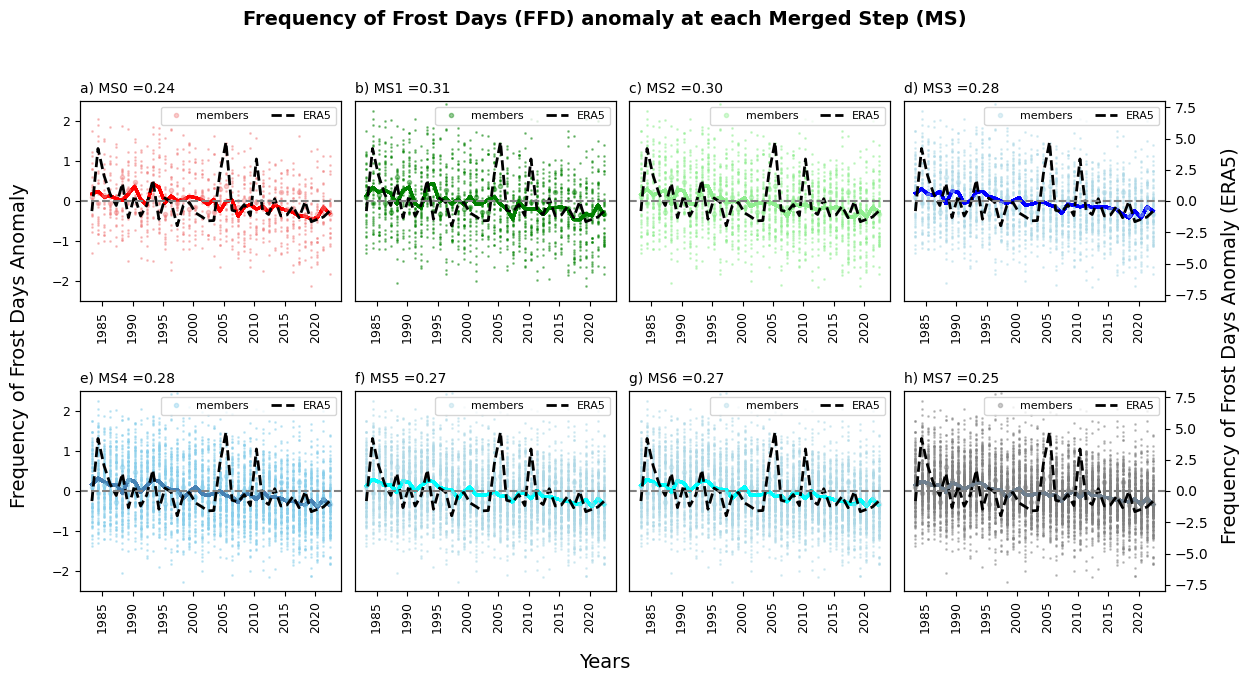

In [169]:
f,ax = plt.subplots(2,4,figsize=(14,7))
ax=ax.ravel()
f.subplots_adjust(top=0.85,bottom=0.15, hspace=0.45, wspace=0.05)

from matplotlib.ticker import MultipleLocator

years=np.arange(1983,2023)

for i in arange(0,24):

    ax[0].xaxis.set_tick_params(labelsize=9)
    ax[0].yaxis.set_tick_params(labelsize=9)
    ax[0].tick_params(axis='x', labelrotation=90)   
    ax[0].set_ylim([-2.5,2.5])
    ax[0].yaxis.set_major_locator(MultipleLocator(1))
#    ax[0].axes.get_yaxis().set_ticks([])
    ax[0].plot(dt,merge0_fcst_1.fd[i,:],color='lightcoral',marker='o',lw=0,markersize=1,alpha=0.4)
    ax[0].plot(dt,ensmean_merge0,color='red',lw=2,linestyle='solid',label='ensmean') 

ax0 = ax[0].twinx() 
ax0.plot(dt,merge0_fcst_1.fd[0,:],color='lightcoral',marker='o',lw=0,label='members',markersize=3,alpha=0.4)
ax0.set_ylim([-8,8])
ax0.axes.get_yaxis().set_ticks([])
######ax1.plot(dt,ensmean_merge0,color='red',lw=2,linestyle='solid',label='ensmean') 

ax0.plot(dt,era5_index_1.fd,color='black',lw=2,linestyle='dashed',label='ERA5')
ax0.legend(fontsize=8,ncols=2,loc='upper right') 
ax0.axhline(0,linestyle='dashed',color='gray')

#ax[0].xaxis.set_tick_params(labelsize=9)
#ax[0].yaxis.set_tick_params(labelsize=9)
#ax[0].tick_params(axis='x', labelrotation=90)   
#ax[0].set_ylim([-2,2])
#ax[0].yaxis.set_major_locator(MultipleLocator(1))
#ax[0].plot(dt,ensmean_merge0,color='red',lw=2,linestyle='solid',label='ensmean') 

#ax0 = ax[0].twinx() 
#for i in arange(0,24):
#    ax0.set_ylim([-8,8])
#    ax0.axes.get_yaxis().set_ticks([])
#    ax0.plot(dt,merge0_fcst_1.fd[i,:],color='lightcoral',marker='o',lw=0,markersize=1,alpha=0.4)


for i in arange(0,39):

    ax[1].xaxis.set_tick_params(labelsize=9)
    ax[1].yaxis.set_tick_params(labelsize=9)
    ax[1].tick_params(axis='x', labelrotation=90)   
    ax[1].set_ylim([-2.5,2.5])
    ax[1].yaxis.set_major_locator(MultipleLocator(1))
    ax[1].axes.get_yaxis().set_ticks([])
    ax[1].plot(dt,merge1_fcst_1.fd[i,:],color='green',marker='o',lw=0,markersize=1,alpha=0.4)
    ax[1].plot(dt,ensmean_merge1,color='green',lw=2,linestyle='solid',label='ensmean') 


ax1 = ax[1].twinx() 
ax1.plot(dt,merge1_fcst_1.fd[0,:],color='green',marker='o',lw=0,label='members',markersize=3,alpha=0.4)
ax1.set_ylim([-8,8])
ax1.axes.get_yaxis().set_ticks([])
#ax1.plot(dt,ensmean_merge0,color='red',lw=2,linestyle='solid',label='ensmean') 

ax1.plot(dt,era5_index_1.fd,color='black',lw=2,linestyle='dashed',label='ERA5')

ax1.legend(fontsize=8,ncols=2,loc='upper right') 
ax1.axhline(0,linestyle='dashed',color='gray')



for i in arange(0,54):

    ax[2].xaxis.set_tick_params(labelsize=9)
    ax[2].yaxis.set_tick_params(labelsize=9)
    ax[2].tick_params(axis='x', labelrotation=90)   
    ax[2].set_ylim([-2.5,2.5])
    ax[2].yaxis.set_major_locator(MultipleLocator(1))
    ax[2].axes.get_yaxis().set_ticks([])
    ax[2].plot(dt,merge2_fcst_1.fd[i,:],color='lightgreen',marker='o',lw=0,markersize=1,alpha=0.4)
    ax[2].plot(dt,ensmean_merge2,color='lightgreen',lw=2,linestyle='solid',label='ensmean') 


ax2 = ax[2].twinx() 
ax2.plot(dt,merge2_fcst_1.fd[0,:],color='lightgreen',marker='o',lw=0,label='members',markersize=3,alpha=0.4)
ax2.set_ylim([-8,8])
ax2.axes.get_yaxis().set_ticks([])
#ax1.plot(dt,ensmean_merge0,color='red',lw=2,linestyle='solid',label='ensmean') 

ax2.plot(dt,era5_index_1.fd,color='black',lw=2,linestyle='dashed',label='ERA5')

ax2.legend(fontsize=8,ncols=2,loc='upper right') 
ax2.axhline(0,linestyle='dashed',color='gray')


for i in arange(0,79):

    ax[3].xaxis.set_tick_params(labelsize=9)
    ax[3].yaxis.set_tick_params(labelsize=9)
    ax[3].tick_params(axis='x', labelrotation=90)   
    ax[3].set_ylim([-2.5,2.5])
    ax[3].yaxis.set_major_locator(MultipleLocator(1))
    ax[3].axes.get_yaxis().set_ticks([])
    ax[3].plot(dt,merge3_fcst_1.fd[i,:],color='lightblue',marker='o',lw=0,markersize=1,alpha=0.4)
    ax[3].plot(dt,ensmean_merge3,color='blue',lw=2,linestyle='solid',label='ensmean') 


ax3 = ax[3].twinx() 
ax3.plot(dt,merge3_fcst_1.fd[0,:],color='lightblue',marker='o',lw=0,label='members',markersize=3,alpha=0.4)
ax3.set_ylim([-8,8])
#ax3.axes.get_yaxis().set_ticks([])
#ax1.plot(dt,ensmean_merge0,color='red',lw=2,linestyle='solid',label='ensmean') 

ax3.plot(dt,era5_index_1.fd,color='black',lw=2,linestyle='dashed',label='ERA5')

ax3.legend(fontsize=8,ncols=2,loc='upper right') 
ax3.axhline(0,linestyle='dashed',color='gray')



for i in arange(0,130):

    ax[4].xaxis.set_tick_params(labelsize=9)
    ax[4].yaxis.set_tick_params(labelsize=9)
    ax[4].tick_params(axis='x', labelrotation=90)   
    ax[4].set_ylim([-2.5,2.5])
    ax[4].yaxis.set_major_locator(MultipleLocator(1))
#    ax[4].axes.get_yaxis().set_ticks([])
    ax[4].plot(dt,merge4_fcst_1.fd[i,:],color='skyblue',marker='o',lw=0,markersize=1,alpha=0.4)
    ax[4].plot(dt,ensmean_merge4,color='steelblue',lw=2,linestyle='solid',label='ensmean') 


ax4 = ax[4].twinx() 
ax4.plot(dt,merge4_fcst_1.fd[0,:],color='skyblue',marker='o',lw=0,label='members',markersize=3,alpha=0.4)
ax4.set_ylim([-8,8])
ax4.axes.get_yaxis().set_ticks([])
#ax1.plot(dt,ensmean_merge0,color='red',lw=2,linestyle='solid',label='ensmean') 

ax4.plot(dt,era5_index_1.fd,color='black',lw=2,linestyle='dashed',label='ERA5')

ax4.legend(fontsize=8,ncols=2,loc='upper right') 
ax4.axhline(0,linestyle='dashed',color='gray')


for i in arange(0,155):

    ax[5].xaxis.set_tick_params(labelsize=9)
    ax[5].yaxis.set_tick_params(labelsize=9)
    ax[5].tick_params(axis='x', labelrotation=90)   
    ax[5].set_ylim([-2.5,2.5])
    ax[5].yaxis.set_major_locator(MultipleLocator(1))
    ax[5].axes.get_yaxis().set_ticks([])
    ax[5].plot(dt,merge5_fcst_1.fd[i,:],color='lightblue',marker='o',lw=0,markersize=1,alpha=0.4)
    ax[5].plot(dt,ensmean_merge5,color='aqua',lw=2,linestyle='solid',label='ensmean') 


ax5 = ax[5].twinx() 
ax5.plot(dt,merge4_fcst_1.fd[0,:],color='lightblue',marker='o',lw=0,label='members',markersize=3,alpha=0.4)
ax5.set_ylim([-8,8])
ax5.axes.get_yaxis().set_ticks([])
#ax1.plot(dt,ensmean_merge0,color='red',lw=2,linestyle='solid',label='ensmean') 

ax5.plot(dt,era5_index_1.fd,color='black',lw=2,linestyle='dashed',label='ERA5')

ax5.legend(fontsize=8,ncols=2,loc='upper right') 
ax5.axhline(0,linestyle='dashed',color='gray')



for i in arange(0,155):

    ax[6].xaxis.set_tick_params(labelsize=9)
    ax[6].yaxis.set_tick_params(labelsize=9)
    ax[6].tick_params(axis='x', labelrotation=90)   
    ax[6].set_ylim([-2.5,2.5])
    ax[6].yaxis.set_major_locator(MultipleLocator(1))
    ax[6].axes.get_yaxis().set_ticks([])
    ax[6].plot(dt,merge6_fcst_1.fd[i,:],color='lightblue',marker='o',lw=0,markersize=1,alpha=0.4)
    ax[6].plot(dt,ensmean_merge6,color='aqua',lw=2,linestyle='solid',label='ensmean') 


ax6 = ax[6].twinx() 
ax6.plot(dt,merge6_fcst_1.fd[0,:],color='lightblue',marker='o',lw=0,label='members',markersize=3,alpha=0.4)

ax6.set_ylim([-8,8])
ax6.axes.get_yaxis().set_ticks([])
#ax1.plot(dt,ensmean_merge0,color='red',lw=2,linestyle='solid',label='ensmean') 

ax6.plot(dt,era5_index_1.fd,color='black',lw=2,linestyle='dashed',label='ERA5')

ax6.legend(fontsize=8,ncols=2,loc='upper right') 
ax6.axhline(0,linestyle='dashed',color='gray')



for i in arange(0,206):

    ax[7].xaxis.set_tick_params(labelsize=9)
    ax[7].yaxis.set_tick_params(labelsize=9)
    ax[7].tick_params(axis='x', labelrotation=90)   
    ax[7].set_ylim([-2.5,2.5])
    ax[7].yaxis.set_major_locator(MultipleLocator(1))
    ax[7].axes.get_yaxis().set_ticks([])
    ax[7].plot(dt,merge7_fcst_1.fd[i,:],color='grey',marker='o',lw=0,markersize=1,alpha=0.4)
    ax[7].plot(dt,ensmean_merge7,color='slategray',lw=2,linestyle='solid',label='ensmean') 


ax7 = ax[7].twinx() 
ax7.plot(dt,merge7_fcst_1.fd[0,:],color='grey',marker='o',lw=0,label='members',markersize=3,alpha=0.4)
ax7.set_ylim([-8,8])
#ax7.axes.get_yaxis().set_ticks([])
#ax1.plot(dt,ensmean_merge0,color='red',lw=2,linestyle='solid',label='ensmean') 

ax7.plot(dt,era5_index_1.fd,color='black',lw=2,linestyle='dashed',label='ERA5')

ax7.legend(fontsize=8,ncols=2,loc='upper right') 
ax7.axhline(0,linestyle='dashed',color='gray')



f.suptitle('Frequency of Frost Days (FFD) anomaly at each Merged Step (MS)',fontsize=14, weight='bold')
f.text(0.075,0.5, 'Frequency of Frost Days Anomaly', rotation='vertical',fontsize=14,va='center')
f.text(0.94,0.5, 'Frequency of Frost Days Anomaly (ERA5)', rotation='vertical',fontsize=14,va='center')
f.text(0.5,0.04, 'Years', fontsize=14,ha='center')


ax[0].set_title('a) MS0 =%.2f' %skill_m0.statistic,fontsize=10,loc='left')
ax[1].set_title('b) MS1 =%.2f' %skill_m1.statistic,fontsize=10,loc='left')
ax[2].set_title('c) MS2 =%.2f' %skill_m2.statistic ,fontsize=10,loc='left')
ax[3].set_title('d) MS3 =%.2f' %skill_m3.statistic ,fontsize=10,loc='left')
ax[4].set_title('e) MS4 =%.2f' %skill_m4.statistic ,fontsize=10,loc='left')
ax[5].set_title('f) MS5 =%.2f' %skill_m5.statistic ,fontsize=10,loc='left')
ax[6].set_title('g) MS6 =%.2f' %skill_m6.statistic ,fontsize=10,loc='left')
ax[7].set_title('h) MS7 =%.2f' %skill_m7.statistic ,fontsize=10,loc='left')


#plt.savefig(dirfig+"FigureS2_anom_FFDS_all_leads.png",dpi=300,bbox_inches='tight')